# Cluster analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcl
import seaborn as sns
import networkx as nx
import os
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch


plt.rcParams['font.size'] = 7
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42
# affects whiskers, medians, caps (all Line2D)
plt.rcParams['lines.linewidth'] = 0.6

## Data import
- Rome number mapping nodes file (after all group concentrated)
- Edge file (after all group concentrated)

In [2]:
nodes = pd.read_csv("data/3_results/5_network_analysis/5_3_network_align/rome_merged_nodes.csv", sep=',')
edges = pd.read_csv("data/3_results/5_network_analysis/5_3_network_align/merged_edges.csv", sep=',')


## Colormap define
- Same to Cytoscape colormap

In [3]:
color = {
    'I': '#326a81a0',#326a81a0
    'II': '#9fbccaa0',
    'III': '#FDDBC7',
    'IV': '#20854ea0',
    'V': '#EF8A62',
    'VI': '#FFEDA0',
    'VII': '#FEB24C',
    'VIII': '#A8DDB5',
    'IX': '#807DBA',
    'X': '#666666',
    'XI': '#666666'
}


module_color = {
    'I': '#326a81a0',
    'II': '#9fbccaa0',
}

## 1.
1. Cluster properties

In [4]:
def extract_node_group(nodes, group):
    """
    To export that nodes data into specific group(high, low, pibd) at DataFrame.
    
    Parameters
    ----------
    nodes : pd.DataFrame
    group : str
        'high', 'low', 'pibd' 
    
    Returns
    -------
    pd.DataFrame
    """
    
    cols = [
        "Label",
        f"Id_{group}",
        f"cluster_{group}",
        f"degree_{group}",
        f"betweenness_{group}",
        f"closeness_{group}",
        f"eigenvector_{group}",
        f"abundance_{group}",
        "phylum"
    ]
    
    df = nodes[cols].copy()
    

    df = df.dropna(subset=[f"Id_{group}"])
    

    df = df.sort_values(f"cluster_{group}", ascending=True).copy()
    
    return df

In [5]:
## Using

nodes_high = extract_node_group(nodes, "high")
nodes_high = nodes_high[nodes_high["cluster_high"] != '0']
nodes_low = extract_node_group(nodes, "low")
nodes_low = nodes_low[nodes_low["cluster_low"] != '0']
nodes_pibd = extract_node_group(nodes, "pibd")
nodes_pibd = nodes_pibd[nodes_pibd["cluster_pibd"] != '0']

In [6]:
print(nodes_high.count()) ## 99
print(nodes_low.count()) ## 100
print(nodes_pibd.count()) ## 91



Label               99
Id_high             99
cluster_high        99
degree_high         99
betweenness_high    99
closeness_high      99
eigenvector_high    99
abundance_high      99
phylum              99
dtype: int64
Label              100
Id_low             100
cluster_low        100
degree_low         100
betweenness_low    100
closeness_low      100
eigenvector_low    100
abundance_low      100
phylum             100
dtype: int64
Label               91
Id_pibd             91
cluster_pibd        91
degree_pibd         91
betweenness_pibd    91
closeness_pibd      91
eigenvector_pibd    91
abundance_pibd      91
phylum              91
dtype: int64


In [7]:
## Edge data separation by each group.

def edge_separation(edges, group):
    df = edges.loc[edges["group"] == f'{group}_edge'].copy()

    return df

high_edges = edge_separation(edges, 'high')
low_edges = edge_separation(edges, 'low')
pibd_edges = edge_separation(edges, 'pibd')

- Edge counts
    - high: 535
    - low: 356
    - pibd: 233


In [ ]:
print(high_edges["Sign"].value_counts()) ## 535, positive: 329, negative: 206
print(low_edges["Sign"].value_counts()) ## 356, positive: 239, negative: 117
print(pibd_edges["Sign"].value_counts()) ## 233, positive: 184, negative: 49

Sign
Positive    329
Negative    206
Name: count, dtype: int64
Sign
Positive    239
Negative    117
Name: count, dtype: int64
Sign
Positive    184
Negative     49
Name: count, dtype: int64



[high]
cluster_high
I       41
II      34
III      8
IV       5
V        2
VI       2
VII      3
VIII     4
Name: count, dtype: int64

[low]
cluster_low
I      24
II     33
III    24
IV      6
V       5
VI      4
VII     4
Name: count, dtype: int64

[pibd]
cluster_pibd
I       27
II      10
III     15
IV       7
IX       2
V       19
VI       2
VII      2
VIII     2
X        2
XI       3
Name: count, dtype: int64


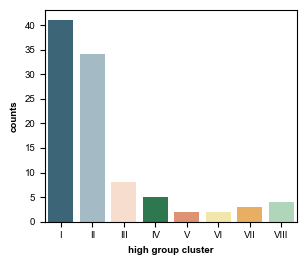

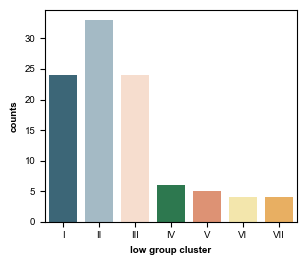

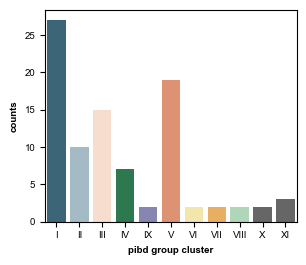

In [ ]:
def plot_cluster_counts(group_dict, palette):
    """
    Each group of cluster count plot + value_counts return
    
    Parameters
    ----------
    group_dict : dict
        {"high": df, "low": df, ...}
    palette : list or dict
        seaborn palette
    
    Returns
    -------
    dict
        {group_name: value_counts Series}
    """
    
    results = {}
    
    for name, df in group_dict.items():
        fig = plt.figure(figsize=(3.25, 2.75))
        ax = fig.add_subplot(111)

        col = f"cluster_{name}"
        
        sns.countplot(
            data=df,
            x=col,
            hue=col,
            palette=palette,
            ax=ax
        )
        
        counts = df[col].value_counts().sort_index()
        results[name] = counts
        
        print(f"\n[{name}]")
        print(counts)
        
        ax.set_xlabel(f"{name} group cluster", fontweight="bold")
        ax.set_ylabel("counts", fontweight="bold")
    
    return results


gr = {
    "high": nodes_high,
    "low": nodes_low,
    "pibd": nodes_pibd
}

results = plot_cluster_counts(gr, color)
table = pd.DataFrame(results)
table.to_csv("data/3_results/6_cluster_analysis/group_cluster_information.csv", sep=',')

In [10]:
gr

{'high':                            Label  Id_high cluster_high  degree_high  \
 0                     Sutterella      1.0            I     0.010638   
 101              Alitiscatomonas    102.0            I     0.005319   
 50                 Merdimmobilis     51.0            I     0.037234   
 49   2_Oscillospiraceae_88309(F)     50.0            I     0.010638   
 47                 Dysosmobacter     48.0            I     0.090426   
 ..                           ...      ...          ...          ...   
 30                 Eubacterium_R     31.0          VII     0.010638   
 36                    Limiplasma     37.0         VIII     0.026596   
 98                        SFLA01     99.0         VIII     0.005319   
 68                    Ventrisoma     69.0         VIII     0.010638   
 74          1_Aristaeellaceae(F)     75.0         VIII     0.015957   
 
      betweenness_high  closeness_high  eigenvector_high  abundance_high  \
 0            0.000000        0.526809          0.

In [11]:
table

,high,low,pibd
I,41.0,24.0,27
II,34.0,33.0,10
III,8.0,24.0,15
IV,5.0,6.0,7
IX,NaN,NaN,2
V,2.0,5.0,19
VI,2.0,4.0,2
VII,3.0,4.0,2
VIII,4.0,NaN,2
X,NaN,NaN,2


### Linear separation network cluster summarize
<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>high</th>
      <th>low</th>
      <th>pibd</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>I</th>
      <td>41.0</td>
      <td>24.0</td>
      <td>27</td>
    </tr>
    <tr>
      <th>II</th>
      <td>34.0</td>
      <td>33.0</td>
      <td>10</td>
    </tr>
    <tr>
      <th>III</th>
      <td>8.0</td>
      <td>24.0</td>
      <td>15</td>
    </tr>
    <tr>
      <th>IV</th>
      <td>5.0</td>
      <td>6.0</td>
      <td>7</td>
    </tr>
    <tr>
      <th>IX</th>
      <td>NaN</td>
      <td>NaN</td>
      <td>2</td>
    </tr>
    <tr>
      <th>V</th>
      <td>2.0</td>
      <td>5.0</td>
      <td>19</td>
    </tr>
    <tr>
      <th>VI</th>
      <td>2.0</td>
      <td>4.0</td>
      <td>2</td>
    </tr>
    <tr>
      <th>VII</th>
      <td>3.0</td>
      <td>4.0</td>
      <td>2</td>
    </tr>
    <tr>
      <th>VIII</th>
      <td>4.0</td>
      <td>NaN</td>
      <td>2</td>
    </tr>
    <tr>
      <th>X</th>
      <td>NaN</td>
      <td>NaN</td>
      <td>2</td>
    </tr>
    <tr>
      <th>XI</th>
      <td>NaN</td>
      <td>NaN</td>
      <td>3</td>
    </tr>
  </tbody>
</table>
</div>

In [12]:
def make_cluster_map(nodes_df, group):
    """
    Label → cluster mapping dictionary create
    """
    return dict(zip(
        nodes_df["Label"],
        nodes_df[f"cluster_{group}"]
    ))


# mapping create
high_map = make_cluster_map(nodes_high, "high")
low_map = make_cluster_map(nodes_low, "low")
pibd_map = make_cluster_map(nodes_pibd, "pibd")


In [13]:
def add_edge_cluster(edges_df, mapping_dict):
    """
    edges Source / Target cluster column create
    """
    df = edges_df.copy()
    
    df["Source cluster"] = df["Source"].map(mapping_dict)
    df["Target cluster"] = df["Target"].map(mapping_dict)
    
    return df

# edge에 cluster create
high_edges = add_edge_cluster(high_edges, high_map)
low_edges = add_edge_cluster(low_edges, low_map)
pibd_edges = add_edge_cluster(pibd_edges, pibd_map)


In [14]:
def add_reference_cluster(edges_df, ref_mapping_dict, ref_name="high"):
    """
    edges Source / Target reference group cluster column 추create
    
    Parameters
    ----------
    edges_df : pd.DataFrame
    ref_mapping_dict : dict
        e.g.: high_map
    ref_name : str
        e.g.: "high"
    
    Returns
    -------
    pd.DataFrame
    """
    df = edges_df.copy()
    
    df[f"Source {ref_name} cluster"] = df["Source"].map(ref_mapping_dict)
    df[f"Target {ref_name} cluster"] = df["Target"].map(ref_mapping_dict)
    
    return df

In [15]:
## low, pibd group high reference cluster create

low_edges_2 = add_reference_cluster(low_edges, high_map, ref_name="high")
pibd_edges_2 = add_reference_cluster(pibd_edges, high_map, ref_name = "high")

### High group each cluster inter-cluster positive interaction counts

In [16]:
def plot_intra_cluster_edges(
    edges_df,
    group,
    palette,
    sign="Positive",
    save_dir=None,
    figsize=(3.25, 2.75)
):
    """
    Specifically group intra-cluster edge count calculate and barplot create
    Parameters
    ----------
    edges_df : pd.DataFrame
        'Source cluster', 'Target cluster', 'Sign' column contains
    group : str
        e.g. 'high', 'low', 'pibd'
    palette : list or dict
        seaborn palette
    sign : str, default='Positive'
        To use edge sign
    save_dir : str, optional
        figure save folder
    figsize : tuple, default=(3.25, 2.75)
        figure size
    
    Returns
    -------
    result_df : pd.DataFrame
        cluster criteria results
    result_df_desc : pd.DataFrame
        edge_counts sorting criteria results
    """
    
    df = edges_df.loc[edges_df["Sign"] == sign].copy()
    df = df.loc[df["Source cluster"] == df["Target cluster"]].copy()

    ## alignment
    roman_order = {
    "I": 1, "II": 2, "III": 3, "IV": 4, "V": 5,
    "VI": 6, "VII": 7, "VIII": 8, "IX": 9, "X": 10
    }
    
    result_df = (
    df["Source cluster"]
    .value_counts()
    .rename_axis("cluster")
    .reset_index(name="edge_counts")
    )

    # Number criteria alignment
    result_df["cluster_order"] = result_df["cluster"].map(roman_order)
    result_df = result_df.sort_values("cluster_order").drop(columns="cluster_order")
    result_df_desc = result_df.sort_values("edge_counts", ascending=False).copy()

    # save folder create
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    # 1. descending sort order
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111)

    sns.barplot(
        data=result_df_desc,
        x="cluster",
        y="edge_counts",
        hue="cluster",
        palette=palette,
        order=result_df_desc["cluster"].tolist(),
        ax=ax
    )
    ax.set_xlabel(f"{group.capitalize()} group cluster (Descending)", fontweight="bold")
    ax.set_ylabel("intra cluster edge counts", fontweight="bold")
    fig.tight_layout()

    if save_dir is not None:
        fig.savefig(
            os.path.join(save_dir, f"ver1_{group}_cluster_interaction.pdf"),
            dpi=300,
            bbox_inches="tight"
        )
    plt.show()

    # 2. cluster sort order
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111)

    sns.barplot(
        data=result_df,
        x="cluster",
        y="edge_counts",
        hue="cluster",
        palette=palette,
        ax=ax
    )
    ax.set_xlabel(f"{group.capitalize()} group cluster", fontweight="bold")
    ax.set_ylabel("intra cluster edge counts", fontweight="bold")
    fig.tight_layout()

    if save_dir is not None:
        fig.savefig(
            os.path.join(save_dir, f"ver2_{group}_cluster_interaction.pdf"),
            dpi=300,
            bbox_inches="tight"
        )
    plt.show()

    return result_df, result_df_desc

### High group each cluster inter-cluster positive interaction counts visualization
- Heatmap


In [17]:
def make_undirected_cluster_crosstab(edges_df, order, source_col="Source cluster", target_col="Target cluster"):
    """
    Undirected network between each cluster interaction count matrix create
    
    Parameters
    ----------
    edges_df : pd.DataFrame
        Source cluster, Target cluster column contained edge dataframe
    order : list
        cluster show order (e.g. ['I', 'II', 'III', 'IV', 'V', 'VI'])
    source_col : str, default='Source cluster'
    target_col : str, default='Target cluster'
    
    Returns
    -------
    pd.DataFrame
        symmetric cluster-cluster crosstab matrix
    """
    edges_df = edges_df[edges_df['Sign'] == 'Positive'].copy()
    df = edges_df[[source_col, target_col]].dropna().copy()
    df = df[
    df[source_col].isin(order) &
    df[target_col].isin(order)]
    
    order_map = {cluster: idx for idx, cluster in enumerate(order)}
    
    # undirected
    sorted_pairs = df.apply(
        lambda row: sorted(
            [row[source_col], row[target_col]],
            key=lambda x: order_map[x]
        ),
        axis=1
    )
    
    df[["cluster_1", "cluster_2"]] = pd.DataFrame(
        sorted_pairs.tolist(),
        index=df.index
    )
    
    # make crosstab
    mat = pd.crosstab(
        df["cluster_2"],
        df["cluster_1"]
    )
    
    # whole cluster ordering
    mat = mat.reindex(index=order, columns=order, fill_value=0)
    
    # matrix
    sym_mat = mat + mat.T
    
    # Diagonal, restoring to original values
    for cl in order:
        sym_mat.loc[cl, cl] = mat.loc[cl, cl]
    
    # align
    sym_mat = sym_mat.reindex(index=order[::-1], columns=order, fill_value=0)
    
    return sym_mat


In [18]:
order = ['I', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII']

high_mat = make_undirected_cluster_crosstab(high_edges, order)
low_mat = make_undirected_cluster_crosstab(low_edges, order)
pibd_mat = make_undirected_cluster_crosstab(pibd_edges, order)

In [19]:
high_mat

cluster_1,I,II,III,IV,V,VI,VII,VIII
cluster_2,,,,,,,,
VIII,2,1,0,0,0,0,0,4
VII,3,0,0,0,0,0,2,0
VI,1,0,0,0,0,1,0,0
V,0,0,0,0,1,0,0,0
IV,0,4,0,4,0,0,0,0
III,7,0,8,0,0,0,0,0
II,1,132,0,4,0,0,0,1
I,158,1,7,0,0,1,3,2


In [20]:
def plot_cluster_heatmap(
    mat,
    group,
    figsize=(2.25, 1.75),
    cmap="Blues",
    annot=True,
    fmt="d",
    cbar=False,
    linewidths=0,
    linecolor="white",
    square=True,
    save_path=None
):
    """
    cluster interaction heatmap visualization and save
    
    Parameters
    ----------
    mat : pd.DataFrame
        cluster x cluster matrix
    group : str
        e.g. 'high', 'low', 'pibd'
    figsize : tuple
    cmap : str
    annot : bool
    fmt : str
    cbar : bool
    linewidths : float
    linecolor : str
    square : bool
    save_path : str or None
    
    Returns
    -------
    fig, ax
    """
    
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111)

    sns.heatmap(
        mat,
        annot=annot,
        fmt=fmt,
        cmap=cmap,
        cbar=cbar,
        linewidths=linewidths,
        linecolor=linecolor,
        square=square,
        ax=ax
    )

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color("black")

    ax.set_xlabel("Source cluster", fontweight="bold")
    ax.set_ylabel("Target cluster", fontweight="bold")
    fig.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    
    return fig, ax


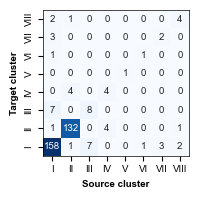

In [422]:
## 07_10_High cluster intra positive edge
order = ['I', 'II', 'III', 'IV', 'V', 'VI','VII', 'VIII']

high_mat = make_undirected_cluster_crosstab(high_edges, order)

fig, ax = plot_cluster_heatmap(
    high_mat,
    group="high",
    figsize=(2.5, 2),
    save_path="figure/7_cluster/linear_separation/cluster_analysis/heat_high_cluster.pdf"
)

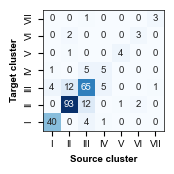

In [424]:
## Low cluster intra positive edge

order = ['I', 'II', 'III', 'IV', 'V', 'VI', 'VII']

low_mat = make_undirected_cluster_crosstab(low_edges, order)

fig, ax = plot_cluster_heatmap(
    low_mat,
    group="low",
    figsize=(2.25, 1.75),
    save_path="figure/7_cluster/linear_separation/cluster_analysis/heat_low_cluster.pdf"
)

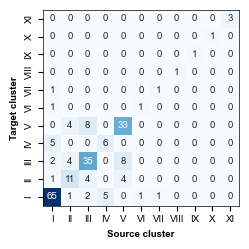

In [425]:
## 07_10_pibd cluster intra positive edge

order = ['I', 'II', 'III', 'IV', 'V', 'VI','VII','VIII', 'IX', 'X', 'XI']

pibd_mat = make_undirected_cluster_crosstab(pibd_edges, order)

fig, ax = plot_cluster_heatmap(
    pibd_mat,
    group="pibd",
    figsize=(3, 2.5),
    save_path="figure/7_cluster/linear_separation/cluster_analysis/heat_pibd_cluster.pdf"
)

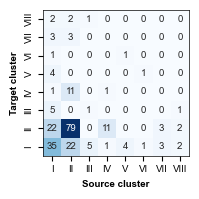

In [426]:
## Low network edge heatmap by high cluster

order = ['I', 'II', 'III', 'IV', 'V', 'VI','VII', 'VIII']


low_highref_mat = make_undirected_cluster_crosstab(
    low_edges_2,
    order=order,
    source_col="Source high cluster",
    target_col="Target high cluster"
)


fig, ax = plot_cluster_heatmap(
    low_highref_mat,
    group="high",
    figsize=(2.5, 2),
    save_path=None
)

ax.set_xlabel("Source high cluster", fontweight="bold")
ax.set_ylabel("Target high cluster", fontweight="bold")

# Save
fig.savefig(
    "figure/7_cluster/linear_separation/cluster_analysis/heat_low_hi_cl.pdf",
    dpi=300,
    bbox_inches="tight"
    
)

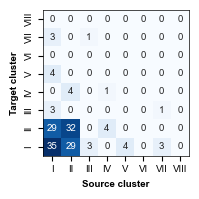

In [427]:
## PIBD network edge heatmap by high cluster

order = ['I', 'II', 'III', 'IV', 'V', 'VI','VII', 'VIII']


pibd_highref_mat = make_undirected_cluster_crosstab(
    pibd_edges_2,
    order=order,
    source_col="Source high cluster",
    target_col="Target high cluster"
)


fig, ax = plot_cluster_heatmap(
    pibd_highref_mat,
    group="high",
    figsize=(2.5, 2),
    save_path=None
)

ax.set_xlabel("Source high cluster", fontweight="bold")
ax.set_ylabel("Target high cluster", fontweight="bold")

fig.savefig(
    "figure/7_cluster/linear_separation/cluster_analysis/heat_pibd_hi_cl.pdf",
    dpi=300,
    bbox_inches="tight"
)

In [394]:
def map_reference_cluster(ref_nodes, target_nodes, ref_group, new_col=None):
    """
    Reference group cluster mapped by target nodes
    
    Parameters
    ----------
    ref_nodes : pd.DataFrame
        reference node dataframe (e.g. nodes_high)
    target_nodes : pd.DataFrame
        mapping applied dataframe (e.g. nodes_low)
    ref_group : str
        Order group label (e.g. 'high')
    new_col : str or None
        Results column label (default: cluster_{ref_group})
    
    Returns
    -------
    pd.DataFrame
    """
    
    if new_col is None:
        new_col = f"cluster_{ref_group}"
    
    mapping = dict(zip(
        ref_nodes["Label"],
        ref_nodes[f"cluster_{ref_group}"]
    ))
    
    df = target_nodes.copy()
    df[new_col] = df["Label"].map(mapping)
    
    return df


In [395]:
## Each nodes files, high group cluster value add.

nodes_low = map_reference_cluster(nodes_high, nodes_low, "high")
nodes_pibd = map_reference_cluster(nodes_high, nodes_pibd, "high")

## 2.
- High group cluster ordered **ClusterI, ClusterII** analysis.
- After, each cluster of properties analysis.


In [396]:
## After cluster map created, cluster intra positive correlation counts.
def make_label_to_cluster_map(nodes_df, cluster_col):
    """
    Label -> cluster dictionary create
    """
    return dict(zip(nodes_df["Label"], nodes_df[cluster_col]))


def calc_intra_cluster_edge_degree(edges_df, cluster, source_node_col="Source", target_node_col="Target",
                                   source_cluster_col="Source_ref", target_cluster_col="Target_ref"):
    """
    To use specific cluster into node, each node edge degree calcuate
    """
    df = edges_df[
        (edges_df[source_cluster_col] == cluster) &
        (edges_df[target_cluster_col] == cluster)
    ].copy()

    source_counts = df[source_node_col].value_counts()
    target_counts = df[target_node_col].value_counts()

    degree = source_counts.add(target_counts, fill_value=0)

    degree_df = (
        degree.rename_axis("Label")
        .reset_index(name="edge_degree")
        .sort_values("edge_degree", ascending=False)
        .reset_index(drop=True)
    )

    return degree_df


def process_module_edge_degree_by_reference(
    reference_nodes,
    edges_dict,
    reference_group="high",
    selected_clusters=("I", "II"),
    sign="Positive",
    save_dir=None,
    cluster_file_suffix=None
):
    """
    reference group of cluster ordered, calculated by intra-cluster edge degree of each group edge.
    
    Parameters
    ----------
    reference_nodes : pd.DataFrame
        reference node dataframe (e.g. nodes_high)
    edges_dict : dict
        {"high": high_edges, "low": low_edges, "pibd": pibd_edges}
    reference_group : str
        reference cluster group label (basically, 'high')
    selected_clusters : tuple/list
        To analyses cluster (e.g. ("I", "II", "IV"))
    sign : str
        To use edge sign (basically, "Positive")
    save_dir : str or None
        csv save path
    cluster_file_suffix : dict or None
        File name suffix
        example: {"I": "i", "II": "ii", "IV": "iii"}
    
    Returns
    -------
    dict
        results[group][cluster] = degree_df
    """
    
    ref_cluster_col = f"cluster_{reference_group}"
    ref_map = make_label_to_cluster_map(reference_nodes, ref_cluster_col)

    if cluster_file_suffix is None:
        cluster_file_suffix = {
            "I": "i",
            "II": "ii",
        }

    results = {}

    for group_name, edges_df in edges_dict.items():
        df = edges_df.copy()

        # To mapped reference cluster at edge
        df["Source_ref"] = df["Source"].map(ref_map)
        df["Target_ref"] = df["Target"].map(ref_map)

        # sign filtering
        df = df[df["Sign"] == sign].copy()

        # edge filtering
        df = df[
            df["Source_ref"].isin(selected_clusters) &
            df["Target_ref"].isin(selected_clusters)
        ].copy()

        results[group_name] = {}

        for cluster in selected_clusters:
            degree_df = calc_intra_cluster_edge_degree(
                df,
                cluster=cluster,
                source_node_col="Source",
                target_node_col="Target",
                source_cluster_col="Source_ref",
                target_cluster_col="Target_ref"
            )

            cluster_rename_map = {
                "I": "I",
                "II": "II",
                }
            
            renamed_cluster = cluster_rename_map.get(cluster, cluster)
            results[group_name][renamed_cluster] = degree_df

            # csv save
            if save_dir is not None:
                os.makedirs(save_dir, exist_ok=True)
                suffix = cluster_file_suffix.get(cluster, cluster.lower())
                renamed_cluster = cluster_rename_map.get(cluster, cluster)

                out_path = os.path.join(
                    save_dir,
                    f"{group_name}_module_{renamed_cluster.lower()}_degree.csv"
                )
                degree_df.to_csv(out_path, sep=",", index=False)

    return results


edges_dict = {
    "high": high_edges,
    "low": low_edges,
    "pibd": pibd_edges
}

In [397]:
## cluster intra positive correlation calculate file.
results = process_module_edge_degree_by_reference(reference_nodes=nodes_high, edges_dict=edges_dict, reference_group="high", selected_clusters=("I", "II"),
                                                  sign="Positive", save_dir=None)

In [398]:
results

{'high': {'I':                           Label  edge_degree
  0          Bacteroides_H_857956         23.0
  1            Alistipes_A_871400         22.0
  2                 Phocaeicola_A         21.0
  3            Alistipes_A_871404         17.0
  4                 Dysosmobacter         17.0
  5                 Lawsonibacter         15.0
  6               Hominicoprocola         15.0
  7                 Barnesiella_B         13.0
  8                       UBA5905         13.0
  9      Parabacteroides_B_862066         11.0
  10           Odoribacter_865974         11.0
  11                    Faecousia         10.0
  12                   Vescimonas         10.0
  13                Acetatifactor         10.0
  14        Parasutterella_564865          9.0
  15  1_Oscillospiraceae_88309(F)          7.0
  16         Eubacterium_G_180878          7.0
  17                Eubacterium_F          7.0
  18           Roseburia_A_166204          7.0
  19                Anaerotruncus          6.0


In [399]:
def plot_module_degree_bar(
    degree_df,
    group,
    module_label,
    threshold,
    save_dir=None,
    figsize=(4, 4.5),
    dark_color="#326a81",
    light_color="#9fbcca"
):
    """
    Each group or cluster, visualized by positive correlation edge count barplot
    
    Parameters
    ----------
    degree_df : pd.DataFrame
        'Label', 'edge_degree' column contain
    group : str
        example: 'high', 'low', 'pibd'
    module_label : str
        example: 'I', 'II', 'III'
    threshold : int or float
        edge_degree sorting
    save_dir : str or None
        figure save path
    figsize : tuple
    dark_color : str
    light_color : str
    
    Returns
    -------
    fig, ax
    """
    
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111)

    colors = [
        dark_color if val >= threshold else light_color
        for val in degree_df["edge_degree"]
    ]

    sns.barplot(
        data=degree_df,
        x="edge_degree",
        y="Label",
        hue="Label",
        palette=colors,
        ax=ax
    )

    ax.set_xlabel("edge counts", fontweight="bold")
    ax.set_ylabel("nodes", fontweight="bold")
    ax.set_title(
        f"{group.capitalize()} group module {module_label} positive correlation",
        fontweight="bold"
    )

    fig.tight_layout()

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        module_num_map = {"I": "1", "II": "2", "III": "3"}
        module_num = module_num_map.get(module_label, module_label)

        fig.savefig(
            os.path.join(save_dir, f"{group}_module{module_num}_degree.pdf"),
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()
    return fig, ax





def plot_all_module_degree_bars(results, thresholds, save_dir=None, figsize=(4, 4.5)):
    """
    All of group of cluster, created positive correlation degree barplot
    
    Parameters
    ----------
    results : dict
        example:
        {
            "high": {"I": df1, "II": df2, "IV": df3},
            "low": {"I": df4, "II": df5, "IV": df6},
            "pibd": {"I": df7, "II": df8, "IV": df9}
        }
    thresholds : dict
        example:
        {
            "high": {"I": 20, "II": 5, "IV": 14},
            "low": {"I": 8, "II": 2, "IV": 6},
            "pibd": {"I": 3, "II": 3, "IV": 5}
        }
    save_dir : str or None
    figsize : tuple
    
    Returns
    -------
    None
    """
    
    module_label_map = {
        "I": "I",
        "II": "II",
        "III": "III"
    }

    for group, module_dict in results.items():
        for cluster_name, degree_df in module_dict.items():
            threshold = thresholds[group][cluster_name]
            module_label = module_label_map[cluster_name]

            plot_module_degree_bar(
                degree_df=degree_df,
                group=group,
                module_label=module_label,
                threshold=threshold,
                save_dir=save_dir,
                figsize=figsize
            )

def prepare_edges_by_reference_cluster(
    edges_df,
    reference_nodes,
    reference_group="high",
    selected_clusters=("I", "II"),
    sign="Positive",
    source_col="Source",
    target_col="Target"
):
    """
    To mapped reference group of cluster at edge of source or target collum,
    filtered by edge into selected cluster, filtering to sign criteria.
    
    Parameters
    ----------
    edges_df : pd.DataFrame
    reference_nodes : pd.DataFrame
        example: nodes_high
    reference_group : str
        example: 'high'
    selected_clusters : tuple/list
        example: ('I', 'II', 'IV')
    sign : str
        example: 'Positive'
    source_col : str
    target_col : str
    
    Returns
    -------
    pd.DataFrame
        Source_ref, Target_ref column added filtered edge dataframe
    """
    
    ref_cluster_col = f"cluster_{reference_group}"
    ref_map = dict(zip(reference_nodes["Label"], reference_nodes[ref_cluster_col]))
    
    df = edges_df.copy()
    df["Source_ref"] = df[source_col].map(ref_map)
    df["Target_ref"] = df[target_col].map(ref_map)
    
    # selected cluster
    df = df[
        df["Source_ref"].isin(selected_clusters) &
        df["Target_ref"].isin(selected_clusters)
    ].copy()
    
    # sign filtering
    df = df[df["Sign"] == sign].copy()
    
    return df


In [400]:
# 1. preprocessing
high_edges_fil = prepare_edges_by_reference_cluster(
    high_edges, nodes_high,
    reference_group="high",
    selected_clusters=("I", "II"),
    sign="Positive"
)

low_edges_fil = prepare_edges_by_reference_cluster(
    low_edges, nodes_high,
    reference_group="high",
    selected_clusters=("I", "II"),
    sign="Positive"
)

pibd_edges_fil = prepare_edges_by_reference_cluster(
    pibd_edges, nodes_high,
    reference_group="high",
    selected_clusters=("I", "II"),
    sign="Positive"
)

In [401]:
low_edges_fil

,Unnamed: 0,Source,Target,Type,Weight,Sign,asso,group,Source cluster,Target cluster,Source_ref,Target_ref
549,14,Gemmiger_A_73129,Ruminococcus_E,Undirected,0.409463,Positive,0.302532,low_edge,III,III,II,II
550,15,Gemmiger_A_73129,Faecalibacillus,Undirected,0.455750,Positive,0.407584,low_edge,III,III,II,II
553,18,Gemmiger_A_73129,Faecalibacterium,Undirected,0.451742,Positive,0.398827,low_edge,III,III,II,I
554,19,Gemmiger_A_73129,Vescimonas,Undirected,0.409348,Positive,0.302260,low_edge,III,I,II,I
556,21,Gemmiger_A_73129,Bariatricus,Undirected,0.458239,Positive,0.412991,low_edge,III,III,II,II
...,...,...,...,...,...,...,...,...,...,...,...,...
863,328,Fusicatenibacter,Roseburia_A_166204,Undirected,0.449938,Positive,0.394863,low_edge,III,III,II,I
869,334,Roseburia_A_166204,Hominilimicola,Undirected,0.432324,Positive,0.355489,low_edge,III,IV,I,I
876,341,Acetatifactor,Faecousia,Undirected,0.410216,Positive,0.304310,low_edge,I,I,I,I
877,342,Alitiscatomonas,Haemophilus_D_735815,Undirected,0.419361,Positive,0.325716,low_edge,II,II,I,I


### Intra positive correlation counts

In [402]:
def count_intra_positive_edges(edges_df, source_cluster_col, target_cluster_col, clusters=None):
    """
    Same cluster intra positive edge count calculate
    
    Parameters
    ----------
    edges_df : pd.DataFrame
    source_cluster_col : str
    target_cluster_col : str
    clusters : list or tuple or None
    
    Returns
    -------
    pd.DataFrame
        columns = ['cluster', 'edge_counts']
    """
    
    df = edges_df.copy()
    
    if "Sign" in df.columns:
        df = df[df["Sign"] == "Positive"].copy()
    
    if clusters is None:
        clusters = sorted(df[source_cluster_col].dropna().unique())
    
    cl_re = {}
    for cl in clusters:
        count = (
            (df[source_cluster_col] == cl) &
            (df[target_cluster_col] == cl)
        ).sum()
        cl_re[cl] = count

    result_df = pd.DataFrame.from_dict(
        cl_re,
        orient="index",
        columns=["edge_counts"]
    )
    result_df.index.name = "cluster"
    result_df = result_df.reset_index()
    
    return result_df


def prepare_module_edge_count_df(edge_count_df, group_name, selected_clusters=("I", "II")):
    """
    Name group, changed to IV->III, leaving only the selected cluster
    
    Parameters
    ----------
    edge_count_df : pd.DataFrame
        columns = ['cluster', 'edge_counts']
    group_name : str
        example: 'High', 'Low', 'PIBD'
    selected_clusters : tuple/list
    
    Returns
    -------
    pd.DataFrame
    """
    
    df = edge_count_df[edge_count_df["cluster"].isin(selected_clusters)].copy()
    df["Group"] = group_name

    df = df.sort_values("cluster", ascending=True).copy()
    
    return df


def plot_module_intra_positive_edges(
    group_dfs,
    palette,
    figsize=(3.375, 2.255),
    save_path=None,
    ylabel="Number of intra positive edges"
):
    """
    Each group cluster intra positive edge count barplot visualization
    
    Parameters
    ----------
    group_dfs : list of tuple
        example: [("High", hi_df), ("Low", low_df), ("PIBD", pibd_df)]
    palette : list or dict
    figsize : tuple
    save_path : str or None
    ylabel : str
    
    Returns
    -------
    fig, axes
    """
    
    fig, axes = plt.subplots(1, len(group_dfs), figsize=figsize, sharey=True)
    
    if len(group_dfs) == 1:
        axes = [axes]
    
    for ax, (name, df) in zip(axes, group_dfs):
        sns.barplot(
            data=df,
            x="cluster",
            y="edge_counts",
            palette=palette,
            hue="cluster",
            ax=ax
        )
        ax.set_title(f"{name} group", fontweight="bold")
        ax.set_xlabel("")
    
    axes[0].set_ylabel(ylabel, fontweight="bold")
    
    fig.tight_layout()
    
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    
    plt.show()
    return fig, axes





In [403]:
# 1. count
hi_count = count_intra_positive_edges(high_edges_fil, "Source_ref", "Target_ref")
low_count = count_intra_positive_edges(low_edges_fil, "Source_ref", "Target_ref")
pibd_count = count_intra_positive_edges(pibd_edges_fil, "Source_ref", "Target_ref")

# 2. manuscript df
hi_df = prepare_module_edge_count_df(hi_count, "High", selected_clusters=("I", "II"))
low_df = prepare_module_edge_count_df(low_count, "Low", selected_clusters=("I", "II"))
pibd_df = prepare_module_edge_count_df(pibd_count, "PIBD", selected_clusters=("I", "II"))
merged_df = pd.concat([hi_df, low_df, pibd_df], ignore_index=True)


### Draw all at once of intra positive correlation plot

In [404]:
group_palette = {
    "High": "#326A81",  
    "Low": "#9FBCCA",
    "PIBD": "#1F3A44"
}


def plot_module_intra_positive_edges(
    group_dfs,
    palette=group_palette,   
    figsize=(3.375, 2.255),
    save_path=None,
    ylabel="Number of intra positive edges"
):

    # 1. merge
    merged_df_list = []
    for name, df in group_dfs:
        tmp = df.copy()
        tmp["Group"] = name
        merged_df_list.append(tmp)

    merged_df = pd.concat(merged_df_list, ignore_index=True)

    # 2. order
    cluster_order = ["I", "II"]
    group_order = [name for name, _ in group_dfs]

    merged_df = merged_df[merged_df["cluster"].isin(cluster_order)].copy()

    # pivot
    plot_df = merged_df.pivot(index="cluster", columns="Group", values="edge_counts")
    plot_df = plot_df.reindex(index=cluster_order, columns=group_order)

    # 3. plotting
    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(len(cluster_order))
    width = 0.35

    for i, group in enumerate(group_order):
        offset = (i - 0.5) * width
        heights = plot_df[group].values

        for j, cl in enumerate(cluster_order):
            ax.bar(
                x[j] + offset,
                heights[j],
                width=width,
                color=palette[group],
                edgecolor="black",
                linewidth=0
            )

    # x축
    ax.set_xticks(x)
    ax.set_xticklabels(cluster_order)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel, fontweight="bold")

    # legend
    legend_elements = [
        Patch(facecolor=palette[g], label=g)
        for g in group_order
    ]

    ax.legend(handles=legend_elements, frameon=False)

    fig.tight_layout()

    if save_path is not None:
        save_dir = os.path.dirname(save_path)
        if save_dir != "":
            os.makedirs(save_dir, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    return fig, ax

In [405]:
group_palette = {
    "High": "#326A81",
    "Low": "#9FBCCA",
    "PIBD": "#1F3A44"
}

def plot_module_intra_positive_edges(
    group_dfs,
    palette=group_palette,
    figsize=(3.375, 2.255),
    save_path=None,
    ylabel="Number of intra positive edges"
):
    # 1. merge
    merged_df_list = []
    for name, df in group_dfs:
        tmp = df.copy()
        tmp["Group"] = name
        merged_df_list.append(tmp)

    merged_df = pd.concat(merged_df_list, ignore_index=True)

    # 2. order
    cluster_order = ["I", "II"]
    group_order = [name for name, _ in group_dfs]

    merged_df = merged_df[merged_df["cluster"].isin(cluster_order)].copy()

    plot_df = merged_df.pivot(index="cluster", columns="Group", values="edge_counts")
    plot_df = plot_df.reindex(index=cluster_order, columns=group_order)

    # if have non exist fill in with 0
    plot_df = plot_df.fillna(0)

    # 3. plotting
    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(len(cluster_order))
    n_groups = len(group_order)

    total_width = 0.75
    width = total_width / n_groups

    for i, group in enumerate(group_order):
        offset = (i - (n_groups - 1) / 2) * width
        heights = plot_df[group].values

        ax.bar(
            x + offset,
            heights,
            width=width,
            color=palette[group],
            edgecolor="black",
            linewidth=0,
            label=group
        )
        cluster_order = ["I", "II"]
        cluster_label_map = {
            "I": "cluster I",
            "II": "cluster II"
        }

    ax.set_xticks(x)
    ax.set_xticklabels([cluster_label_map[c] for c in cluster_order])

    legend_elements = [
        Patch(facecolor=palette[g], label=g)
        for g in group_order
    ]
    ax.legend(handles=legend_elements, frameon=False)

    fig.tight_layout()

    if save_path is not None:
        save_dir = os.path.dirname(save_path)
        if save_dir != "":
            os.makedirs(save_dir, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    return fig, ax

### Dumbbell plot

In [406]:
def plot_module_degree_dumbbell(
    results,
    group_x="high",
    group_y="low",
    module="I",
    top_n=None,
    sort_by="abs_delta",
    save_dir=None,
    figsize=(3.75, 5),
    group_palette=None,
    line_color="gray"
):
    """
    Between two group cluster edge_degree dumbbell plot
    
    Parameters
    ----------
    results : dict
        {"high": {"I": df, "II": df, "III": df}, ...}
    group_x : str
    group_y : str
    module : str
        'I', 'II', 'III'
    top_n : int or None
        Show only top n nodes with large variation
    sort_by : str
        'abs_delta', 'delta', 'x', 'y'
    save_dir : str or None
    figsize : tuple
    color_x : str
    color_y : str
    line_color : str
    
    Returns
    -------
    merged_df, fig, ax
    """
    
    df_x = results[group_x][module].copy()
    df_y = results[group_y][module].copy()

    df_x = df_x.rename(columns={"edge_degree": f"{group_x}_degree"})
    df_y = df_y.rename(columns={"edge_degree": f"{group_y}_degree"})

    merged_df = pd.merge(df_x, df_y, on="Label", how="outer").fillna(0)

    merged_df["delta"] = merged_df[f"{group_y}_degree"] - merged_df[f"{group_x}_degree"]
    merged_df["abs_delta"] = merged_df["delta"].abs()

    # Align order
    if sort_by == "abs_delta":
        merged_df = merged_df.sort_values("abs_delta", ascending=False)
    elif sort_by == "delta":
        merged_df = merged_df.sort_values("delta", ascending=False)
    elif sort_by == "x":
        merged_df = merged_df.sort_values(f"{group_x}_degree", ascending=False)
    elif sort_by == "y":
        merged_df = merged_df.sort_values(f"{group_y}_degree", ascending=False)
    else:
        raise ValueError("sort_by must be one of: 'abs_delta', 'delta', 'x', 'y'")

    # Top n select
    if top_n is not None:
        merged_df = merged_df.head(top_n).copy()

    # dumbbell plot
    merged_df = merged_df.iloc[::-1].reset_index(drop=True)

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111)

    y_positions = np.arange(len(merged_df))

    # line
    for i, row in merged_df.iterrows():
        ax.plot(
            [row[f"{group_x}_degree"], row[f"{group_y}_degree"]],
            [i, i],
            color=line_color,
            alpha=0.7,
            linewidth=1.5
        )

    # scatter
    ax.scatter(
        merged_df[f"{group_x}_degree"],
        y_positions,
        color=group_palette[group_x],
        s=40,
        label=group_x.capitalize(),
        zorder=3
    )

    ax.scatter(
        merged_df[f"{group_y}_degree"],
        y_positions,
        color=group_palette[group_y],
        s=40,
        label=group_y.capitalize(),
        zorder=3
    )

    ax.set_yticks(y_positions)
    ax.set_yticklabels(merged_df["Label"])
    ax.set_xlabel("edge degree", fontweight="bold")
    ax.set_ylabel("nodes", fontweight="bold")
    ax.set_title(
        f"Cluster {module} degree change ({group_x} vs {group_y})",
        fontweight="bold"
    )

    ax.grid(True, axis="x", alpha=0.4)
    ax.legend(frameon=False)

    fig.tight_layout()

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        module_map = {"I": "1", "II": "2"}
        module_num = module_map.get(module, module)

        suffix = f"_top{top_n}" if top_n is not None else ""
        fig.savefig(
            os.path.join(
                save_dir,
                f"{group_x}_{group_y}_module{module_num}_dumbbell{suffix}.pdf"
            ),
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

    return merged_df, fig, ax

def plot_all_module_dumbbell(
    results,
    group_x="high",
    group_y="low",
    modules=["I", "II"],
    top_n=None,
    sort_by="abs_delta",
    save_dir=None,
    figsize=(3.75, 5)
):
    """
    All of cluster, make to dumbbell plot
    """
    
    outputs = {}

    for m in modules:
        merged_df, fig, ax = plot_module_degree_dumbbell(
            results=results,
            group_x=group_x,
            group_y=group_y,
            module=m,
            top_n=top_n,
            sort_by=sort_by,
            save_dir=save_dir,
            figsize=figsize
        )
        outputs[m] = merged_df

    return outputs




In [407]:
group_palette = {
    "high": "#326A81",   # color
    "low": "#9FBCCA",
    "pibd": "#1F3A44"
}


def plot_module_degree_dumbbell(
    results,
    group_x="high",
    group_y="low",
    module="I",
    top_n=None,
    sort_by="abs_delta",
    save_dir=None,
    figsize=(3.75, 5),
    group_palette=group_palette,
    line_color="gray"
):
    """
    Between two group of cluster edge degree dumbbell plot
    """

    if group_palette is None:
        raise ValueError("group_palette must be provided")

    df_x = results[group_x][module].copy()
    df_y = results[group_y][module].copy()

    df_x = df_x.rename(columns={"edge_degree": f"{group_x}_degree"})
    df_y = df_y.rename(columns={"edge_degree": f"{group_y}_degree"})

    merged_df = pd.merge(df_x, df_y, on="Label", how="outer").fillna(0)

    merged_df["delta"] = merged_df[f"{group_y}_degree"] - merged_df[f"{group_x}_degree"]
    merged_df["abs_delta"] = merged_df["delta"].abs()

    # align
    if sort_by == "abs_delta":
        merged_df = merged_df.sort_values("abs_delta", ascending=False)
    elif sort_by == "delta":
        merged_df = merged_df.sort_values("delta", ascending=False)
    elif sort_by == "x":
        merged_df = merged_df.sort_values(f"{group_x}_degree", ascending=False)
    elif sort_by == "y":
        merged_df = merged_df.sort_values(f"{group_y}_degree", ascending=False)
    else:
        raise ValueError("sort_by must be one of: 'abs_delta', 'delta', 'x', 'y'")

    if top_n is not None:
        merged_df = merged_df.head(top_n).copy()

    merged_df = merged_df.iloc[::-1].reset_index(drop=True)

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111)

    y_positions = np.arange(len(merged_df))

    # line
    for i, row in merged_df.iterrows():
        ax.plot(
            [row[f"{group_x}_degree"], row[f"{group_y}_degree"]],
            [i, i],
            color=line_color,
            alpha=0.7,
            linewidth=1.5
        )

    ax.scatter(
        merged_df[f"{group_x}_degree"],
        y_positions,
        color=group_palette[group_x],
        s=40,
        label=group_x,
        zorder=3
    )

    ax.scatter(
        merged_df[f"{group_y}_degree"],
        y_positions,
        color=group_palette[group_y],
        s=40,
        label=group_y,
        zorder=3
    )

    ax.set_yticks(y_positions)
    ax.set_yticklabels(merged_df["Label"])

    # High group order top 10% taxa export
    threshold = merged_df[f"{group_x}_degree"].quantile(0.9)

    top_taxa = merged_df.loc[
        merged_df[f"{group_x}_degree"] >= threshold,
        "Label"
    ].tolist()

# ytick label style applied
    for label in ax.get_yticklabels():

        label.set_fontstyle("italic")

        if label.get_text() in top_taxa:
            label.set_fontweight("bold")
    ax.set_xlabel("edge degree", fontweight="bold")
    ax.set_ylabel("nodes", fontweight="bold")
    ax.set_title(
        f"Cluster {module} degree change ({group_x} vs {group_y})",
        fontweight="bold"
    )

    ax.grid(True, axis="x", alpha=0.4)
    ax.legend(frameon=False, loc="best")

    fig.tight_layout()

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        module_map = {"I": "1", "II": "2"}
        module_num = module_map.get(module, module)


        suffix = f"_top{top_n}" if top_n is not None else ""
        fig.savefig(
            os.path.join(
                save_dir,
                f"{group_x}_{group_y}_module{module_num}_dumbbell{suffix}.pdf"
            ),
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

    return merged_df, fig, ax

def plot_all_module_dumbbell(
    results,
    group_x="high",
    group_y="low",
    modules=["I", "II"],
    top_n=None,
    sort_by="abs_delta",
    save_dir=None,
    figsize=(3.75, 5),
    group_palette=None
):
    outputs = {}

    for m in modules:
        merged_df, fig, ax = plot_module_degree_dumbbell(
            results=results,
            group_x=group_x,
            group_y=group_y,
            module=m,
            top_n=top_n,
            sort_by=sort_by,
            save_dir=save_dir,
            figsize=figsize,
            group_palette=group_palette
        )
        outputs[m] = merged_df

    return outputs

In [408]:
results

{'high': {'I':                           Label  edge_degree
  0          Bacteroides_H_857956         23.0
  1            Alistipes_A_871400         22.0
  2                 Phocaeicola_A         21.0
  3            Alistipes_A_871404         17.0
  4                 Dysosmobacter         17.0
  5                 Lawsonibacter         15.0
  6               Hominicoprocola         15.0
  7                 Barnesiella_B         13.0
  8                       UBA5905         13.0
  9      Parabacteroides_B_862066         11.0
  10           Odoribacter_865974         11.0
  11                    Faecousia         10.0
  12                   Vescimonas         10.0
  13                Acetatifactor         10.0
  14        Parasutterella_564865          9.0
  15  1_Oscillospiraceae_88309(F)          7.0
  16         Eubacterium_G_180878          7.0
  17                Eubacterium_F          7.0
  18           Roseburia_A_166204          7.0
  19                Anaerotruncus          6.0


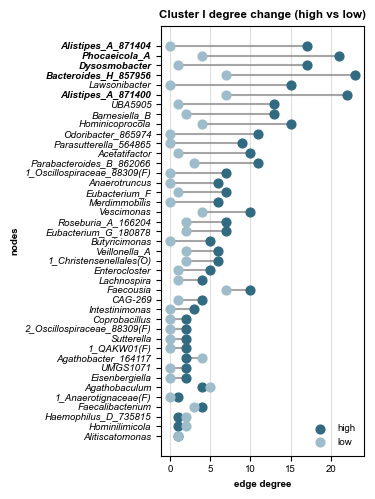

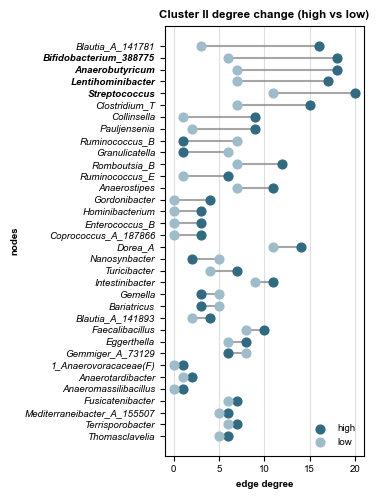

{'I':                           Label  high_degree  low_degree  delta  abs_delta
 0               Alitiscatomonas          1.0         1.0    0.0        0.0
 1                Hominilimicola          1.0         2.0    1.0        1.0
 2          Haemophilus_D_735815          1.0         2.0    1.0        1.0
 3              Faecalibacterium          4.0         3.0   -1.0        1.0
 4          1_Anaerotignaceae(F)          1.0         0.0   -1.0        1.0
 5                 Agathobaculum          4.0         5.0    1.0        1.0
 6                Eisenbergiella          2.0         0.0   -2.0        2.0
 7                      UMGS1071          2.0         0.0   -2.0        2.0
 8           Agathobacter_164117          2.0         4.0    2.0        2.0
 9                   1_QAKW01(F)          2.0         0.0   -2.0        2.0
 10                   Sutterella          2.0         0.0   -2.0        2.0
 11  2_Oscillospiraceae_88309(F)          2.0         0.0   -2.0        2.0
 12    

In [ ]:
## descending rank
plot_all_module_dumbbell(
    results=results,
    group_x="high",
    group_y="low",
    group_palette=group_palette,
    modules=["I", "II"],
    sort_by="abs_delta",
    save_dir="figure/7_cluster/corr_dumbbell/intra/"
)

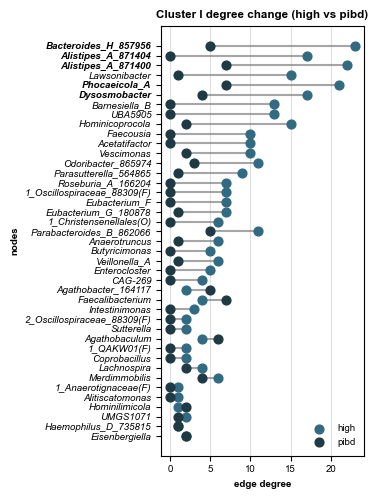

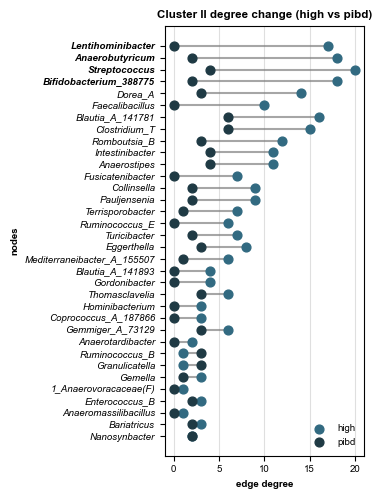

{'I':                           Label  high_degree  pibd_degree  delta  abs_delta
 0                Eisenbergiella          2.0          2.0    0.0        0.0
 1          Haemophilus_D_735815          1.0          1.0    0.0        0.0
 2                      UMGS1071          2.0          1.0   -1.0        1.0
 3                Hominilimicola          1.0          2.0    1.0        1.0
 4               Alitiscatomonas          1.0          0.0   -1.0        1.0
 5          1_Anaerotignaceae(F)          1.0          0.0   -1.0        1.0
 6                 Merdimmobilis          6.0          4.0   -2.0        2.0
 7                   Lachnospira          4.0          2.0   -2.0        2.0
 8                 Coprobacillus          2.0          0.0   -2.0        2.0
 9                   1_QAKW01(F)          2.0          0.0   -2.0        2.0
 10                Agathobaculum          4.0          6.0    2.0        2.0
 11                   Sutterella          2.0          0.0   -2.0      

In [ ]:
## descending rank
plot_all_module_dumbbell(
    results=results,
    group_x="high",
    group_y="pibd",
    modules=["I", "II"],
    sort_by="abs_delta",
    group_palette=group_palette,
    save_dir="figure/7_cluster/corr_dumbbell/intra/"
)

## Whole network order

In [411]:
## Degree calculate

def calc_edge_degree(edges_df, Sign = "Positive", source_node_col="Source", target_node_col="Target"):
    edges_df = edges_df[edges_df["Sign"] == Sign].copy()
    
    source_counts = edges_df[source_node_col].value_counts()
    target_counts = edges_df[target_node_col].value_counts()

    degree = source_counts.add(target_counts, fill_value=0)

    degree_df = (
        degree.rename_axis("Label")
        .reset_index(name="edge_degree")
        .sort_values("edge_degree", ascending=False)
        .reset_index(drop=True)
    )

    return degree_df


high_degree = calc_edge_degree(high_edges)
low_degree = calc_edge_degree(low_edges)
pibd_degree = calc_edge_degree(pibd_edges)

In [412]:
def calc_intra_cluster_edge_degree(edges_df, cluster, source_node_col="Source", target_node_col="Target",
                                   source_cluster_col="Source_ref", target_cluster_col="Target_ref"):
    """
    Whole positive network, after each node edge degree calculated, return at into reference cluster node.
    """

    source_counts = edges_df[source_node_col].value_counts()
    target_counts = edges_df[target_node_col].value_counts()

    degree = source_counts.add(target_counts, fill_value=0)

    degree_df = (
        degree.rename_axis("Label")
        .reset_index(name="edge_degree")
        .sort_values("edge_degree", ascending=False)
        .reset_index(drop=True)
    )

    # node
    cluster_nodes = set(
        edges_df.loc[
            edges_df[source_cluster_col] == cluster,
            source_node_col
        ].tolist()
        +
        edges_df.loc[
            edges_df[target_cluster_col] == cluster,
            target_node_col
        ].tolist()
    )

    degree_df = degree_df[degree_df["Label"].isin(cluster_nodes)].copy()

    return degree_df

In [413]:
def process_module_edge_degree_by_reference(
    reference_nodes,
    edges_dict,
    reference_group="high",
    selected_clusters=("I", "II"),
    sign="Positive",
    save_dir=None,
    cluster_file_suffix=None
):
    """
    Reference group cluster order, each group edge calculate to intra-cluster edge degree
    
    Parameters
    ----------
    reference_nodes : pd.DataFrame
        Order node dataframe (example: nodes_high)
    edges_dict : dict
        {"high": high_edges, "low": low_edges, "pibd": pibd_edges}
    reference_group : str
        Order cluster group name (basically, 'high')
    selected_clusters : tuple/list
        Analysis cluster (e.g. ("I", "II", "IV"))
    sign : str
        To use edge sign (basically, "Positive")
    save_dir : str or None
        csv Save path
    cluster_file_suffix : dict or None
        File name suffix
        example: {"I": "i", "II": "ii", "IV": "iii"}
    
    Returns
    -------
    dict
        results[group][cluster] = degree_df
    """
    
    ref_cluster_col = f"cluster_{reference_group}"
    ref_map = make_label_to_cluster_map(reference_nodes, ref_cluster_col)

    if cluster_file_suffix is None:
        cluster_file_suffix = {
            "I": "i",
            "II": "ii",
        }

    results = {}

    for group_name, edges_df in edges_dict.items():
        df = edges_df.copy()

        # reference cluster mapping by edge
        df["Source_ref"] = df["Source"].map(ref_map)
        df["Target_ref"] = df["Target"].map(ref_map)

        # sign filtering
        df = df[df["Sign"] == sign].copy()

        results[group_name] = {}

        for cluster in selected_clusters:
            degree_df = calc_intra_cluster_edge_degree(
                df,
                cluster=cluster,
                source_node_col="Source",
                target_node_col="Target",
                source_cluster_col="Source_ref",
                target_cluster_col="Target_ref"
            )

            cluster_rename_map = {
                "I": "I",
                "II": "II",
                }
            
            renamed_cluster = cluster_rename_map.get(cluster, cluster)
            results[group_name][renamed_cluster] = degree_df

            # csv save
            if save_dir is not None:
                os.makedirs(save_dir, exist_ok=True)
                suffix = cluster_file_suffix.get(cluster, cluster.lower())
                renamed_cluster = cluster_rename_map.get(cluster, cluster)

                out_path = os.path.join(
                    save_dir,
                    f"{group_name}_module_{renamed_cluster.lower()}_degree.csv"
                )
                degree_df.to_csv(out_path, sep=",", index=False)

    return results


In [414]:
edges_dict = {
    "high": high_edges,
    "low": low_edges,
    "pibd": pibd_edges
}

In [ ]:
## all positive correlation calculate file.
results_1 = process_module_edge_degree_by_reference(reference_nodes=nodes_high, edges_dict=edges_dict, reference_group="high", selected_clusters=("I", "II"),
                                                  sign="Positive", save_dir="data/3_results/6_cluster_analysis/corr_counts")

In [416]:
results_1

{'high': {'I':                           Label  edge_degree
  0          Bacteroides_H_857956         23.0
  1            Alistipes_A_871400         22.0
  3                 Phocaeicola_A         21.0
  4               Hominicoprocola         18.0
  7                 Dysosmobacter         17.0
  8            Alistipes_A_871404         17.0
  12                Lawsonibacter         15.0
  13                Barnesiella_B         14.0
  15                    Faecousia         13.0
  16                      UBA5905         13.0
  17     Parabacteroides_B_862066         12.0
  19           Odoribacter_865974         11.0
  22                   Vescimonas         11.0
  24                Acetatifactor         10.0
  26        Parasutterella_564865          9.0
  29                Eubacterium_F          8.0
  32                Merdimmobilis          7.0
  33           Roseburia_A_166204          7.0
  34  1_Oscillospiraceae_88309(F)          7.0
  35         Eubacterium_G_180878          7.0


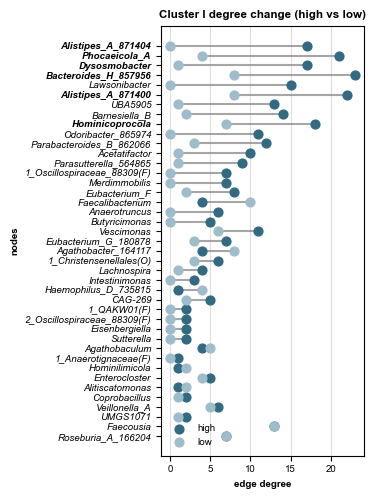

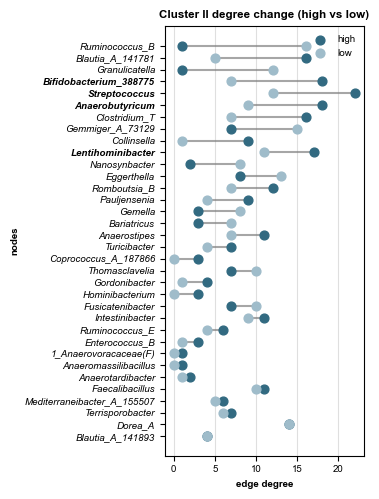

{'I':                           Label  high_degree  low_degree  delta  abs_delta
 0            Roseburia_A_166204          7.0         7.0    0.0        0.0
 1                     Faecousia         13.0        13.0    0.0        0.0
 2                      UMGS1071          2.0         1.0   -1.0        1.0
 3                 Veillonella_A          6.0         5.0   -1.0        1.0
 4                 Coprobacillus          2.0         1.0   -1.0        1.0
 5               Alitiscatomonas          1.0         2.0    1.0        1.0
 6                 Enterocloster          5.0         4.0   -1.0        1.0
 7                Hominilimicola          1.0         2.0    1.0        1.0
 8          1_Anaerotignaceae(F)          1.0         0.0   -1.0        1.0
 9                 Agathobaculum          4.0         5.0    1.0        1.0
 10                   Sutterella          2.0         0.0   -2.0        2.0
 11               Eisenbergiella          2.0         0.0   -2.0        2.0
 12  2_

In [ ]:
## descending rank
plot_all_module_dumbbell(
    results=results_1,
    group_x="high",
    group_y="low",
    group_palette=group_palette,
    modules=["I", "II"],
    sort_by="abs_delta",
    save_dir="figure/7_cluster/corr_dumbbell/high_low"
)

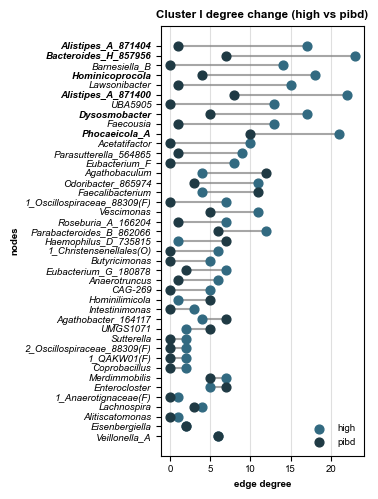

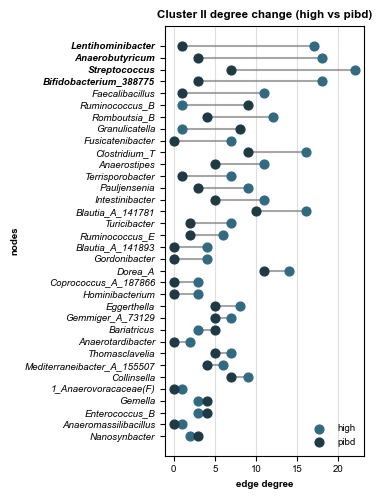

{'I':                           Label  high_degree  pibd_degree  delta  abs_delta
 0                 Veillonella_A          6.0          6.0    0.0        0.0
 1                Eisenbergiella          2.0          2.0    0.0        0.0
 2               Alitiscatomonas          1.0          0.0   -1.0        1.0
 3                   Lachnospira          4.0          3.0   -1.0        1.0
 4          1_Anaerotignaceae(F)          1.0          0.0   -1.0        1.0
 5                 Enterocloster          5.0          7.0    2.0        2.0
 6                 Merdimmobilis          7.0          5.0   -2.0        2.0
 7                 Coprobacillus          2.0          0.0   -2.0        2.0
 8                   1_QAKW01(F)          2.0          0.0   -2.0        2.0
 9   2_Oscillospiraceae_88309(F)          2.0          0.0   -2.0        2.0
 10                   Sutterella          2.0          0.0   -2.0        2.0
 11                     UMGS1071          2.0          5.0    3.0      

In [ ]:
## descending rank
plot_all_module_dumbbell(
    results=results_1,
    group_x="high",
    group_y="pibd",
    group_palette=group_palette,
    modules=["I", "II"],
    sort_by="abs_delta",
    save_dir="figure/7_cluster/corr_dumbbell/high_pibd"
)

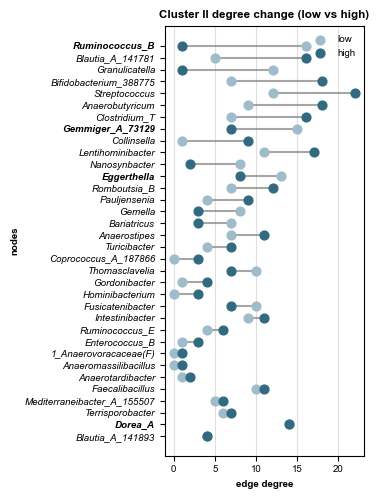

{'II':                           Label  low_degree  high_degree  delta  abs_delta
 0              Blautia_A_141893         4.0          4.0    0.0        0.0
 1                       Dorea_A        14.0         14.0    0.0        0.0
 2              Terrisporobacter         6.0          7.0    1.0        1.0
 3   Mediterraneibacter_A_155507         5.0          6.0    1.0        1.0
 4               Faecalibacillus        10.0         11.0    1.0        1.0
 5             Anaerotardibacter         1.0          2.0    1.0        1.0
 6         Anaeromassilibacillus         0.0          1.0    1.0        1.0
 7         1_Anaerovoracaceae(F)         0.0          1.0    1.0        1.0
 8                Enterococcus_B         1.0          3.0    2.0        2.0
 9                Ruminococcus_E         4.0          6.0    2.0        2.0
 10              Intestinibacter         9.0         11.0    2.0        2.0
 11             Fusicatenibacter        10.0          7.0   -3.0        3.0
 12   

In [ ]:
## descending rank
plot_all_module_dumbbell(
    results=results_1,
    group_x="low",
    group_y="high",
    group_palette=group_palette,
    modules=["II"],
    sort_by="abs_delta",
    save_dir="figure/7_cluster/corr_dumbbell/low_high"
)

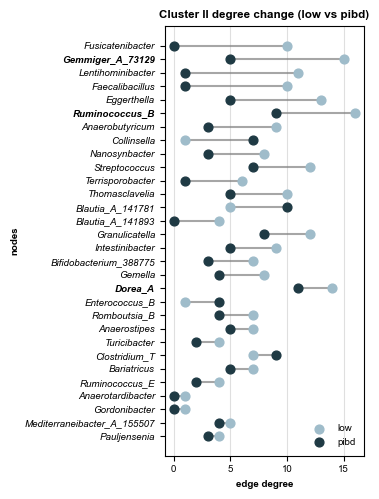

{'II':                           Label  low_degree  pibd_degree  delta  abs_delta
 0                  Pauljensenia         4.0          3.0   -1.0        1.0
 1   Mediterraneibacter_A_155507         5.0          4.0   -1.0        1.0
 2                 Gordonibacter         1.0          0.0   -1.0        1.0
 3             Anaerotardibacter         1.0          0.0   -1.0        1.0
 4                Ruminococcus_E         4.0          2.0   -2.0        2.0
 5                   Bariatricus         7.0          5.0   -2.0        2.0
 6                 Clostridium_T         7.0          9.0    2.0        2.0
 7                  Turicibacter         4.0          2.0   -2.0        2.0
 8                  Anaerostipes         7.0          5.0   -2.0        2.0
 9                  Romboutsia_B         7.0          4.0   -3.0        3.0
 10               Enterococcus_B         1.0          4.0    3.0        3.0
 11                      Dorea_A        14.0         11.0   -3.0        3.0
 12   

In [ ]:
## descending rank
plot_all_module_dumbbell(
    results=results_1,
    group_x="low",
    group_y="pibd",
    group_palette=group_palette,
    modules=["II"],
    sort_by="abs_delta",
    save_dir="figure/7_cluster/corr_dumbbell/low_pibd"
)